<a href="https://colab.research.google.com/github/Dannn17/CV-Klasifikasi_citra_rupiah/blob/main/2418901HamdanNa'imKlasifikasiCitraUangNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *1. Import semua modul Library yang dibutuhkan*

In [1]:
from natsort import natsorted
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
sns.set_theme ( style = "darkgrid")
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

import matplotlib.image as mpimg
import random
from skimage.io import imread
import cv2
import xgboost
from PIL.Image import open

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from keras.layers import InputLayer, MaxPooling2D, Flatten, Dense, Conv2D, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions, ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

# *2. Import Dataset*

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_path = "/content/drive/MyDrive/COMVIS/Dataset_EkstratsiFitur_uang.xlsx"

try:
    df = pd.read_excel(file_path)

    print("--- 7 Kolom Pertama ---")
    print(df.iloc[:, 0:7].head().to_string())
    print(df.iloc[:, 7:].head().to_string())

except Exception as e:
    print(f"Gagal membaca file: {e}")
    print("Pastikan nama file dan path sudah sesuai.")

Mounted at /content/drive
--- 7 Kolom Pertama ---
  file_name   hue_mean  saturation_mean  value_mean    hue_std  saturation_std  value_std
0     2.jpg  68.012911        27.391389  155.898511  45.974248       26.091056  47.683320
1     6.jpg  66.091933        29.955011  140.467500  46.572372       27.254423  47.447229
2     3.jpg  77.897722        31.686044  133.308089  43.118931       26.878961  46.255634
3     5.jpg  72.177411        31.452411  138.636133  41.195482       28.153169  47.055387
4     4.jpg  63.668133        30.476700  140.017833  42.456753       27.502037  48.775352
   texture_contrast  label
0       1152.884916  2RIBU
1       1109.113556  2RIBU
2        889.443512  2RIBU
3       1133.960948  2RIBU
4       1112.256767  2RIBU


# *3. Data Cleansing, Cek ada tidaknya nilai null pada dataset*

In [3]:
print (df.isnull().sum())

file_name           0
hue_mean            0
saturation_mean     0
value_mean          0
hue_std             0
saturation_std      0
value_std           0
texture_contrast    0
label               0
dtype: int64


# *4. Baca informasi terkait dataset*

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file_name         120 non-null    object 
 1   hue_mean          120 non-null    float64
 2   saturation_mean   120 non-null    float64
 3   value_mean        120 non-null    float64
 4   hue_std           120 non-null    float64
 5   saturation_std    120 non-null    float64
 6   value_std         120 non-null    float64
 7   texture_contrast  120 non-null    float64
 8   label             120 non-null    object 
dtypes: float64(7), object(2)
memory usage: 8.6+ KB
None


# *5. Baca Deskripsi Statistik Dataset*

In [5]:
print(df.describe().to_string())

         hue_mean  saturation_mean  value_mean     hue_std  saturation_std   value_std  texture_contrast
count  120.000000       120.000000  120.000000  120.000000      120.000000  120.000000        120.000000
mean    65.378267        59.708375  165.898545   39.019786       38.288279   41.168875       1046.884201
std     31.053972        19.881620   18.664555   14.597281       10.516988    5.514021        263.037157
min     21.130367        26.587333  123.463700   22.055478       19.091970   29.169227        561.141371
25%     36.444544        47.134917  154.660231   30.414272       27.995441   38.524942        901.977068
50%     68.075256        60.737083  164.629717   33.962320       40.369390   40.394566       1041.102681
75%     91.081622        74.572511  180.611003   41.961702       48.609885   45.709764       1165.513016
max    115.790111        98.910133  209.932033   75.129288       52.761266   50.509475       1684.155429


# *6. Skalakan Data untuk meminimalisir error Prediksi*



In [6]:
from sklearn.preprocessing import LabelEncoder

df = df.rename(columns={'label': 'Class'})

le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
scalable = ['hue_mean', 'saturation_mean', 'value_mean', 'hue_std', 'saturation_std', 'value_std', 'texture_contrast']
df[scalable] = StandardScaler().fit_transform(df[scalable])

print(df.describe().to_string())

           hue_mean  saturation_mean    value_mean       hue_std  saturation_std     value_std  texture_contrast       Class
count  1.200000e+02     1.200000e+02  1.200000e+02  1.200000e+02    1.200000e+02  1.200000e+02      1.200000e+02  120.000000
mean   2.053913e-16    -8.511710e-17 -4.440892e-16 -3.330669e-16    7.401487e-17 -7.022161e-16      4.477900e-16    3.500000
std    1.004193e+00     1.004193e+00  1.004193e+00  1.004193e+00    1.004193e+00  1.004193e+00      1.004193e+00    2.300895
min   -1.430845e+00    -1.672898e+00 -2.283085e+00 -1.167028e+00   -1.832920e+00 -2.185331e+00     -1.854413e+00    0.000000
25%   -9.356303e-01    -6.350678e-01 -6.046453e-01 -5.920004e-01   -9.827904e-01 -4.815032e-01     -5.532097e-01    1.750000
50%    8.721255e-02     5.195865e-02 -6.826565e-02 -3.479190e-01    1.987106e-01 -1.410142e-01     -2.207202e-02    3.500000
75%    8.311699e-01     7.507668e-01  7.915617e-01  2.023837e-01    9.855373e-01  8.269699e-01      4.528874e-01    5.250000


# *7. Menampilkan Distribusi Variabel Target (Class)*

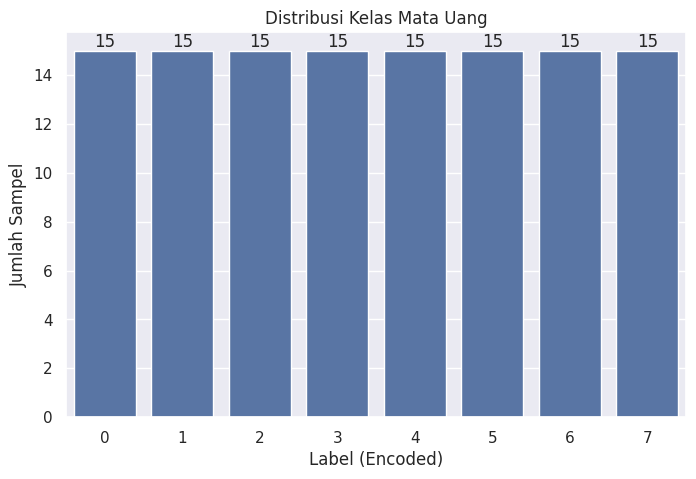

Kelas 0 (100RIBU): 15 sampel (12.5%)
Kelas 1 (10RIBU): 15 sampel (12.5%)
Kelas 2 (1RIBU): 15 sampel (12.5%)
Kelas 3 (20RIBU): 15 sampel (12.5%)
Kelas 4 (2RIBU): 15 sampel (12.5%)
Kelas 5 (50RIBU): 15 sampel (12.5%)
Kelas 6 (5RIBU): 15 sampel (12.5%)
Kelas 7 (75RIBU): 15 sampel (12.5%)


In [7]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")

ax = sns.countplot(x='Class', data=df)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas Mata Uang")
plt.xlabel("Label (Encoded)")
plt.ylabel("Jumlah Sampel")
plt.show()

for class_val in sorted(df['Class'].unique()):
    count = df['Class'].value_counts()[class_val]
    percentage = round(count / len(df) * 100, 2)
    original_label = le.inverse_transform([class_val])[0]
    print(f'Kelas {class_val} ({original_label}): {count} sampel ({percentage}%)')

#*8. Fitur Homogeneity berdasarkan Class*

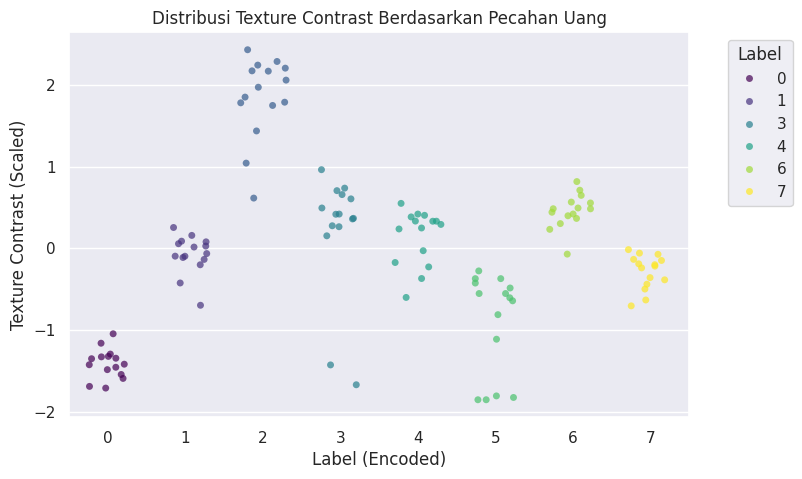

In [8]:
plt.figure(figsize=(8,5))
sns.set_style("darkgrid")

sns.stripplot(
    x='Class',
    y='texture_contrast',
    data=df,
    hue='Class',
    jitter=0.3,
    size=5,
    alpha=0.7,
    dodge=False,
    palette='viridis'
)

plt.title('Distribusi Texture Contrast Berdasarkan Pecahan Uang')
plt.xlabel('Label (Encoded)')
plt.ylabel('Texture Contrast (Scaled)')
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# *9. Menampilkan Distribusi fitur Mean vs Entropy vs Class*

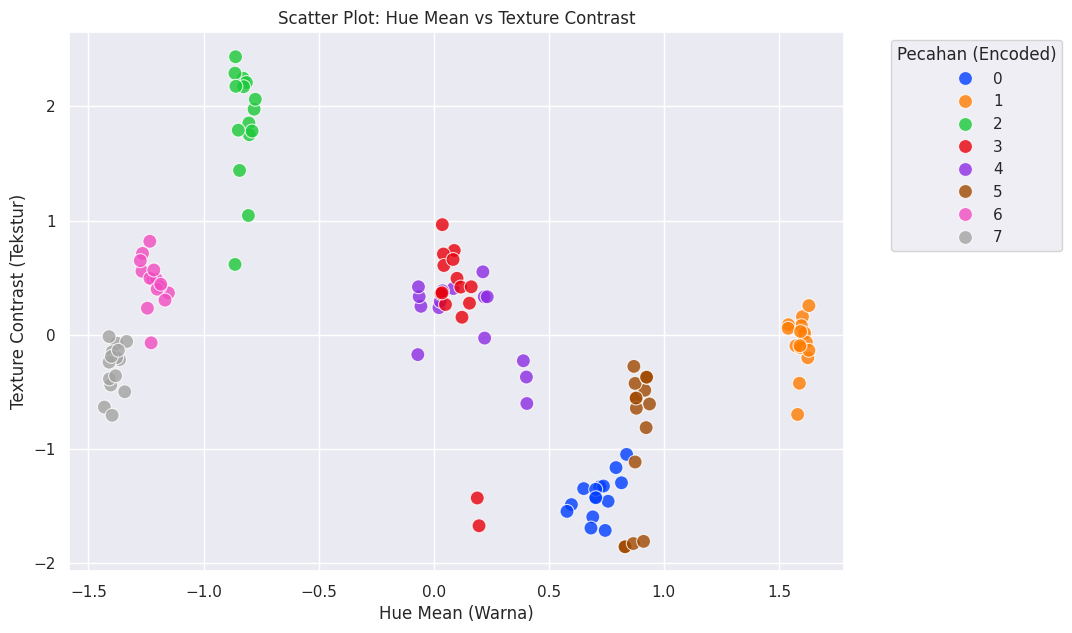

In [9]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='hue_mean', y='texture_contrast', hue='Class', data=df, palette='bright', s=100, alpha=0.8)

plt.title('Scatter Plot: Hue Mean vs Texture Contrast')
plt.xlabel('Hue Mean (Warna)')
plt.ylabel('Texture Contrast (Tekstur)')
plt.legend(title='Pecahan (Encoded)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

#*10. Distribusi fitur Energy berdasarkan Class dan distribusi fitur Entropy berdasarkan Class*

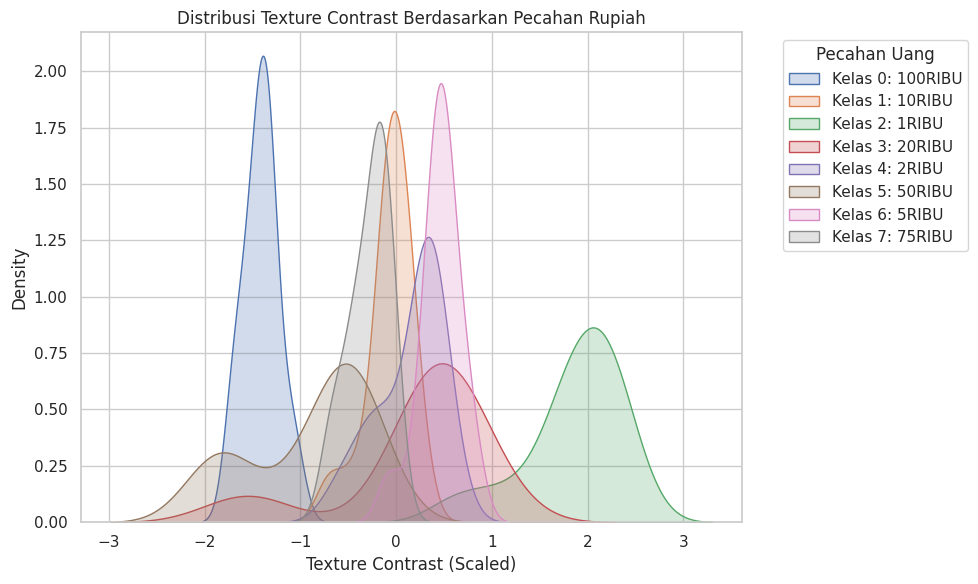

In [10]:
sns.set_style("whitegrid")

_data = df.drop('file_name', axis=1)

plt.figure(figsize=(10, 6))

for class_val in sorted(df['Class'].unique()):
    original_label = le.inverse_transform([class_val])[0]
    subset = _data[_data['Class'] == class_val]
    sns.kdeplot(subset['texture_contrast'],
                fill=True,
                label=f"Kelas {class_val}: {original_label}")

plt.title("Distribusi Texture Contrast Berdasarkan Pecahan Rupiah")
plt.xlabel("Texture Contrast (Scaled)")
plt.ylabel("Density")

plt.legend(title="Pecahan Uang", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# *11. Tampilkan Matirks Korelasi*

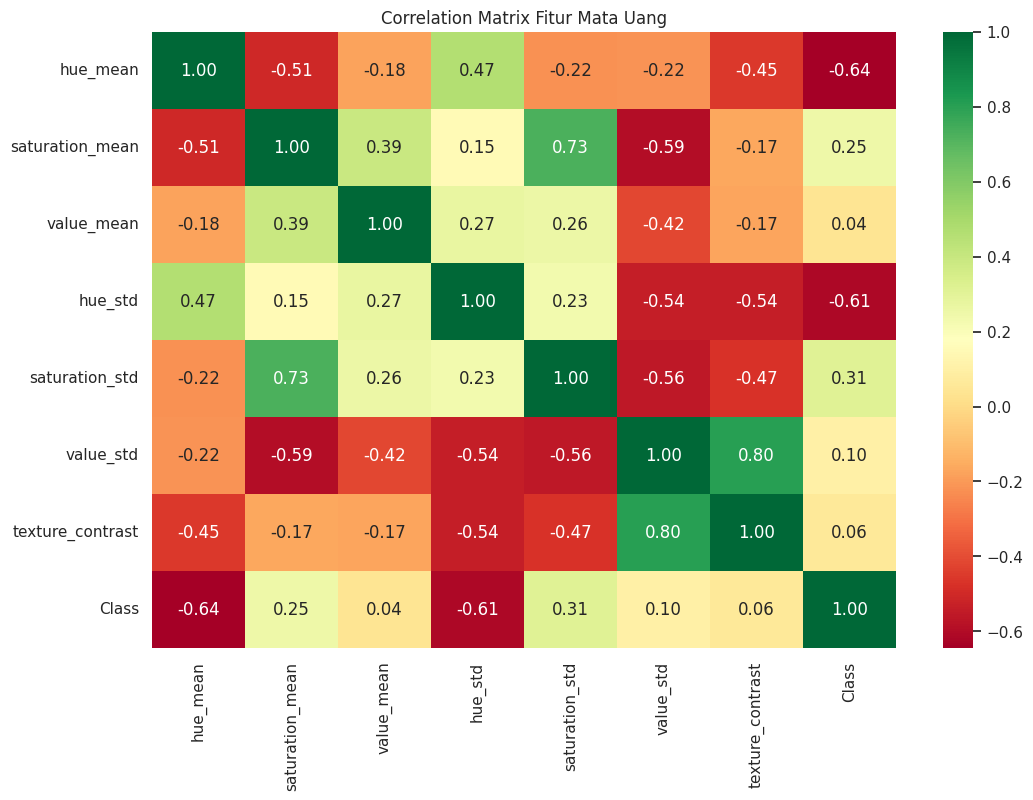

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
corrdata = df.drop('file_name', axis=1).corr()

sns.heatmap(corrdata, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)
plt.title("Correlation Matrix Fitur Mata Uang")
plt.show()

# *12. Hitung dan tampilkan korelasi antara tiap fitur dengan variabel target (Class)*

Nilai Korelasi Fitur terhadap Class:
hue_mean           -0.643900
saturation_mean     0.250201
value_mean          0.041266
hue_std            -0.612164
saturation_std      0.308776
value_std           0.098502
texture_contrast    0.059801
dtype: float64


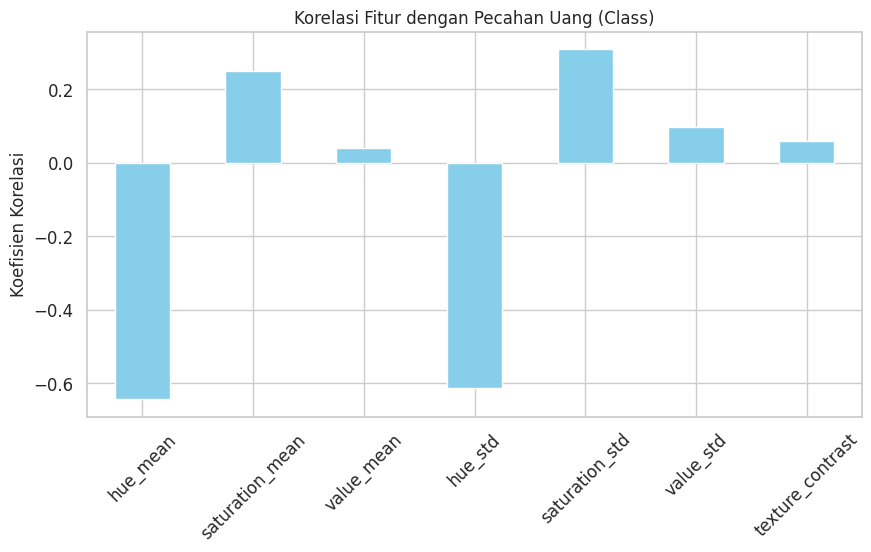

In [12]:
X = df.drop(['file_name', 'Class'], axis=1)
Y = df['Class']

plt.figure(figsize=(10, 5))
correlation_with_target = X.corrwith(Y)
print("Nilai Korelasi Fitur terhadap Class:")
print(correlation_with_target)

correlation_with_target.plot.bar(
    title="Korelasi Fitur dengan Pecahan Uang (Class)",
    fontsize=12,
    rot=45,
    grid=True,
    color='skyblue'
)
plt.ylabel("Koefisien Korelasi")
plt.show()

13

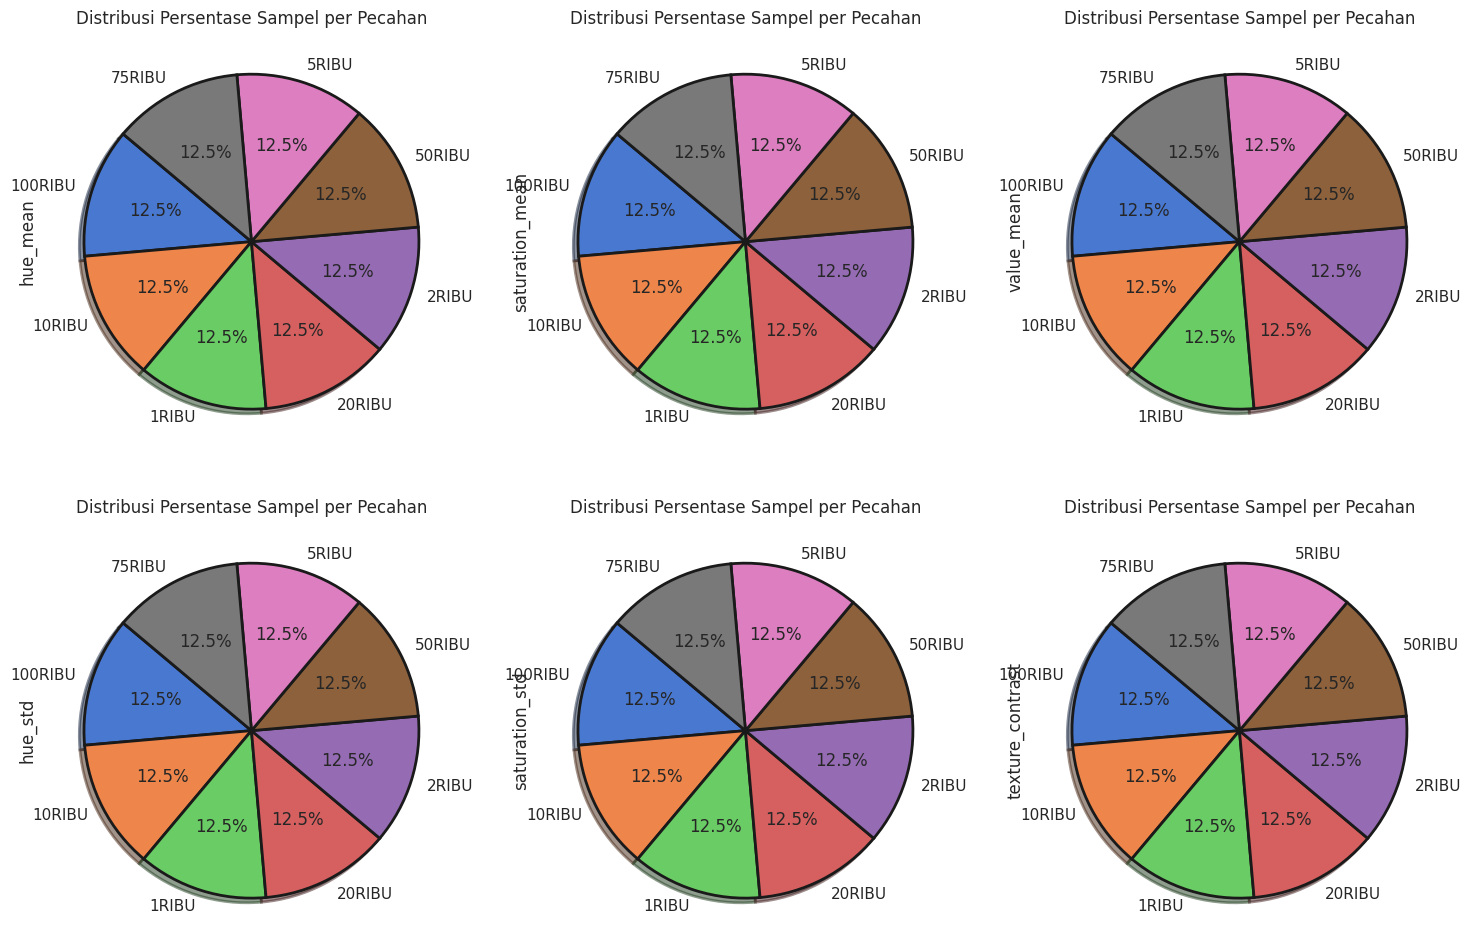

In [17]:
def plot_dist_class_pie(data, ax=None):
    class_counts = data['Class'].value_counts().sort_index()
    labels = le.inverse_transform(class_counts.index)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        class_counts,
        autopct="%1.1f%%",
        labels=labels,
        colors=sns.color_palette("muted"),
        startangle=140,
        wedgeprops={"linewidth":2, "edgecolor":"k"},
        shadow=True
    )
    ax.set_title("Distribusi Persentase Sampel per Pecahan")
    features_to_plot = ['hue_mean', 'saturation_mean', 'value_mean', 'hue_std', 'saturation_std', 'texture_contrast']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot, 1):
    ax = plt.subplot(2, 3, i)
    plot_dist_class_pie(df, ax=ax)
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# *14. Bagi dataset menjadi data pelatihan dan data pengujian*

In [15]:
X = df.drop(['file_name', 'Class'], axis=1)
Y = df['Class']

print(f"X shape: {X.shape}")
print(f"y shape: {Y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=9)

print('X train shape: ', X_train.shape)
print('y train shape: ', y_train.shape)
print('X test shape: ', X_test.shape)
print('y test shape: ', y_test.shape)

X shape: (120, 7)
y shape: (120,)
X train shape:  (96, 7)
y train shape:  (96,)
X test shape:  (24, 7)
y test shape:  (24,)


# *15. Bangun dan latih model Naive Bayes*

Hasil Prediksi (sebagian):
[3 4 6 1 4 0 6 3 1 2 0 3 5 3 6 7 7 7 6 6 6 6 2 3]


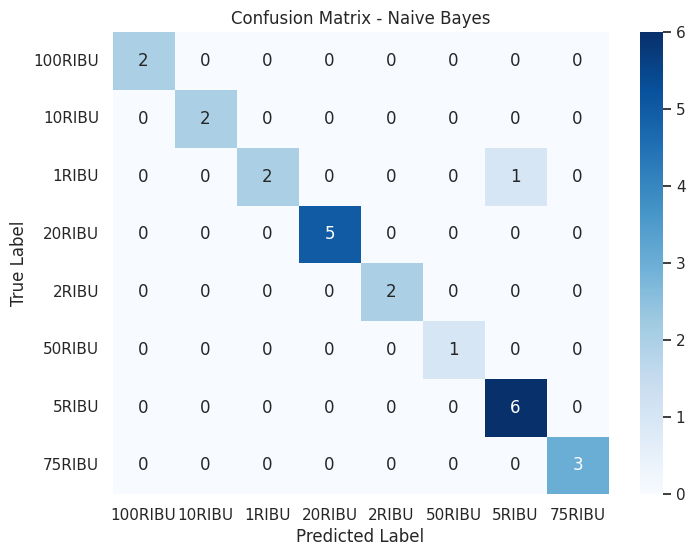

Akurasi Model Naive Bayes: 95.83%

Classification Report:
              precision    recall  f1-score   support

     100RIBU       1.00      1.00      1.00         2
      10RIBU       1.00      1.00      1.00         2
       1RIBU       1.00      0.67      0.80         3
      20RIBU       1.00      1.00      1.00         5
       2RIBU       1.00      1.00      1.00         2
      50RIBU       1.00      1.00      1.00         1
       5RIBU       0.86      1.00      0.92         6
      75RIBU       1.00      1.00      1.00         3

    accuracy                           0.96        24
   macro avg       0.98      0.96      0.97        24
weighted avg       0.96      0.96      0.96        24



In [20]:
def plot_cm(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.inverse_transform(sorted(np.unique(y_true))),
                yticklabels=le.inverse_transform(sorted(np.unique(y_true))))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

nbcla = GaussianNB()
nbcla.fit(X_train, y_train)
pred_nb = nbcla.predict(X_test)

print("Hasil Prediksi (sebagian):")
print(pred_nb)


nbcla_cm = plot_cm(y_test, pred_nb, "Naive Bayes")

score_nbcla = nbcla.score(X_test, y_test)
print(f'Akurasi Model Naive Bayes: {score_nbcla * 100:.2f}%')
print("\nClassification Report:")
target_names_str = [str(x) for x in le.classes_]
print(classification_report(y_test, pred_nb, target_names=target_names_str))

#*17. Menampilkan Batas Keputusan*

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but GaussianNB was fitted with feature names

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning:

You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.



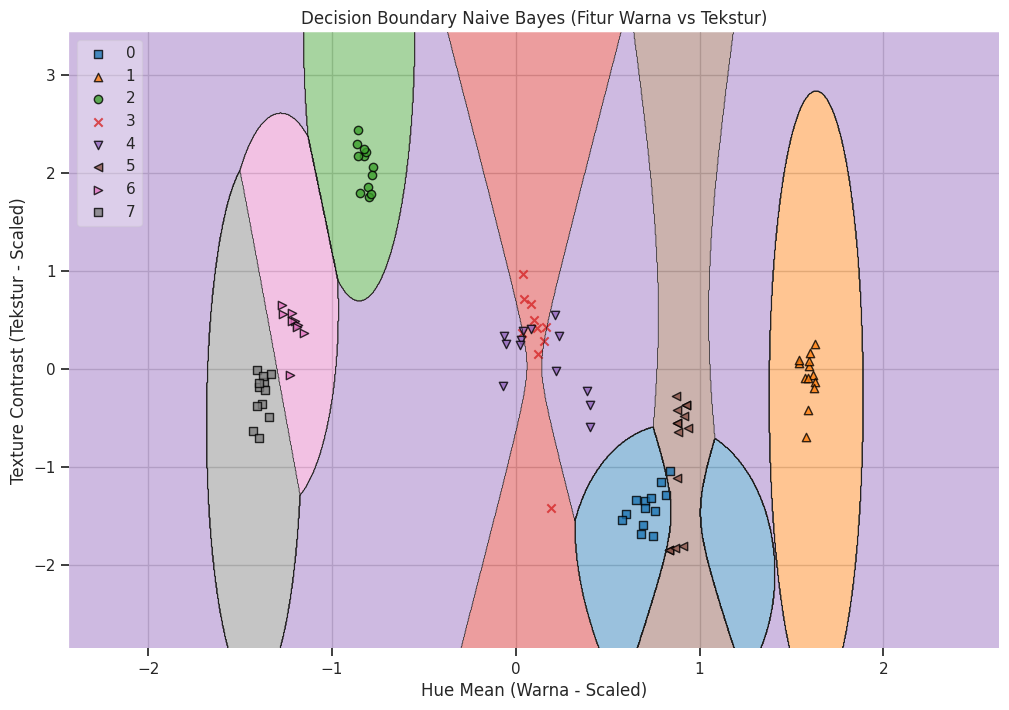

Hasil Prediksi (sebagian):
[4 4 6 1 4 0 6 3 1 2 0 3 5 3 6 7 7 7 6 4 6 6 2 3]
Akurasi Model (Hanya menggunakan 2 fitur): 91.67%


In [19]:
from mlxtend.plotting import plot_decision_regions

X_train_feature = X_train[['hue_mean', 'texture_contrast']]
y_train_feature = y_train
X_test_feature = X_test[['hue_mean', 'texture_contrast']]
y_test_feature = y_test

nbcla_feat = GaussianNB()
nbcla_feat.fit(X_train_feature, y_train_feature)

plt.figure(figsize=(12, 8))
plot_decision_regions(X_train_feature.values, y_train_feature.values,
                      clf=nbcla_feat, legend=2)

plt.title("Decision Boundary Naive Bayes (Fitur Warna vs Tekstur)")
plt.xlabel("Hue Mean (Warna - Scaled)")
plt.ylabel("Texture Contrast (Tekstur - Scaled)")
plt.show()

pred_nb_feat = nbcla_feat.predict(X_test_feature)
print("Hasil Prediksi (sebagian):")
print(pred_nb_feat)

# Menampilkan akurasi khusus untuk model 2 fitur
score_nbcla_feat = nbcla_feat.score(X_test_feature, y_test_feature)
print(f"Akurasi Model (Hanya menggunakan 2 fitur): {score_nbcla_feat * 100:.2f}%")